In [1]:
import pandas as pd
import glob
import numpy as np
from sentence_transformers import SentenceTransformer, util
from tqdm import tqdm
import torch
import sys
import os
import matplotlib.pyplot as plt

# Add the parent directory to sys.path so src can be imported
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

import src.utils as utils

In [2]:
# Leer archivo parquet
chunks_df = pd.read_parquet(r"..\data\processed\chunks.parquet")

# Ver columnas
print("Columnas disponibles:", chunks_df.columns)

Columnas disponibles: Index(['id_doc', 'autor_doc', 'fecha_doc', 'diario_doc', 'titulo_doc',
       'chunk_id', 'texto_chunk'],
      dtype='object')


In [3]:
len(chunks_df)

35319

In [4]:
model = SentenceTransformer('sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2')

In [5]:
# PARTE 1: Cargar términos y crear embeddings por subcategoría

def cargar_subcategorias(path_dir):
    """
    Lee los archivos .txt en el directorio, 
    genera embeddings de cada término con sentence-transformers,
    y devuelve el embedding promedio de cada subcategoría.
    """
    subcat_embeddings = {}
    for file_path in glob.glob(os.path.join(path_dir, "*.txt")):
        subcat = os.path.splitext(os.path.basename(file_path))[0]
        with open(file_path, "r", encoding="utf-8") as f:
            terms = [line.strip() for line in f if line.strip()]
        
        term_embeddings = model.encode(terms, convert_to_tensor=True, show_progress_bar=False)
        avg_embedding = term_embeddings.mean(dim=0)  # promedio de embeddings
        subcat_embeddings[subcat] = avg_embedding
    
    return subcat_embeddings

# PARTE 2: Calcular embeddings chunks

def obtener_embeddings_chunks(
    chunks_df,
    model,
    batch_size=64,
    save_path="../data/processed/chunk_embeddings.npy",
    RELOAD=False
):
    """
    Calcula o carga embeddings de los chunks según el valor de RELOAD.
    
    Args:
        chunks_df (pd.DataFrame): DataFrame con columna 'texto_chunk'
        model: modelo de sentence-transformers
        batch_size (int): tamaño del lote para encoding
        save_path (str): ruta donde guardar/cargar embeddings
        RELOAD (bool): si True, recalcula embeddings aunque exista archivo
    
    Returns:
        np.ndarray con embeddings de los chunks
    """
    
    if not RELOAD and os.path.exists(save_path):
        print(f"Embeddings encontrados en {save_path}, cargando...")
        embeddings = np.load(save_path)
        print(f"Embeddings cargados con forma: {embeddings.shape}")
        return embeddings
    
    print("Calculando embeddings desde cero...")
    textos = chunks_df["texto_chunk"].tolist()
    chunk_embeddings = model.encode(
        textos,
        batch_size=batch_size,
        convert_to_tensor=True,
        show_progress_bar=True
    )

    embeddings_np = chunk_embeddings.cpu().numpy()

    # Crear carpeta si no existe
    os.makedirs(os.path.dirname(save_path), exist_ok=True)

    # Guardar embeddings
    np.save(save_path, embeddings_np)
    print(f"Embeddings calculados y guardados en {save_path}")

    return embeddings_np

# PARTE 3: Calcular similitudes

def calcular_similitudes_chunks(chunks_df, chunk_embeddings, subcat_embeddings):
    """
    Calcula similitudes coseno entre embeddings de chunks y de subcategorías.
    
    Args:
        chunks_df (pd.DataFrame): DataFrame original con 'chunk_id', 'id_doc', 'texto_chunk'
        chunk_embeddings (np.ndarray o tensor): embeddings precomputados
        subcat_embeddings (dict): {subcat: tensor de embedding promedio}
    
    Returns:
        pd.DataFrame con similitudes por subcategoría
    """
    # Convertir a tensores
    chunk_embeddings = torch.tensor(chunk_embeddings)
    subcats = list(subcat_embeddings.keys())
    subcat_matrix = torch.stack(list(subcat_embeddings.values()))

    # Calcular similitudes en bloque
    sim_matrix = util.cos_sim(chunk_embeddings, subcat_matrix).cpu().numpy()

    # Armar DataFrame de resultados
    sim_df = pd.DataFrame(sim_matrix, columns=subcats)
    sim_df.insert(0, "chunk_id", chunks_df["chunk_id"].values)
    sim_df.insert(1, "id_doc", chunks_df["id_doc"].values)
    sim_df.insert(2, "texto_chunk", chunks_df["texto_chunk"].values)

    return sim_df


# PARTE 4: Aplicar umbral y asignar categorías

def asignar_categorias(df, umbral=0.30):
    """
    Añade columnas con las categorías detectadas por chunk
    y sus scores.
    """
    categorias_detectadas = []
    for _, fila in df.iterrows():
        cats = []
        for col in df.columns:
            if col not in ["chunk_id", "id_doc", "texto_chunk"]:
                if fila[col] >= umbral:
                    cats.append((col, fila[col]))
        categorias_detectadas.append(cats if cats else [("ninguna", 0)])
    
    df["categorias_detectadas"] = categorias_detectadas
    return df

# Cálculo de similitudes
Fragmentos columnas vs subcategorías de ciencia

In [6]:
# 1. Cargar embeddings de subcategorías
dir_tesauro = r"..\data\external\terminos\Tesauro_Unesco_Ciencia"
subcat_embeddings = cargar_subcategorias(dir_tesauro)

In [7]:
# 2. Calcular embeddings de chunks y guardarlos
chunk_embeddings = obtener_embeddings_chunks(
    chunks_df,
    model,
    batch_size=64,
    save_path="../data/processed/chunk_embeddings.npy",
    RELOAD=False   # cambiar a True si quieres forzar el recálculo
)

Embeddings encontrados en ../data/processed/chunk_embeddings.npy, cargando...
Embeddings cargados con forma: (35319, 384)


In [8]:
# 3. Calcular similitudes con subcategorías
sim_df = calcular_similitudes_chunks(
    chunks_df,
    chunk_embeddings,
    subcat_embeddings
)

In [9]:
# Definir ruta de salida
results_dir = r"..\data\results"
os.makedirs(results_dir, exist_ok=True)  # crear carpeta si no existe

output_path = os.path.join(results_dir, "similitudes_chunks.xlsx")

# Guardar el DataFrame en Excel
sim_df.to_excel(output_path, index=False, engine="openpyxl")

print(f"Resultados guardados en {output_path}")

Resultados guardados en ..\data\results\similitudes_chunks.xlsx


In [10]:
# 4. Asignar categorías con umbral
umbral_elegido = 0.4
resultado = asignar_categorias(sim_df, umbral=umbral_elegido)
resultado.head()

,chunk_id,id_doc,texto_chunk,Ciencias_ambientales_ingenieria,Ciencias_espacio,Ciencias_fisicas,Ciencias_Geografia_oceanografia,Ciencias_medicas,Ciencias_metereologia,Ciencias_naturales,...,Ciencias_quimicas,Ciencias_tierra,Ciencia_Administracion_ciencia_investigacion,Ciencia_biologia,Ciencia_enfoque_cientifico,Ciencia_hidrologia,Ciencia_matematicas_estadistica,Ciencia_patologia,Ciencia_recursos_naturales,categorias_detectadas
0,0,1,"La Coalición Colombia Partido Alianza Verde, P...",0.174166,0.075071,0.040563,0.164438,0.130477,0.134615,0.154414,...,0.037479,0.176187,0.146089,0.049712,0.143269,0.124779,0.141718,0.197204,0.154686,"[(ninguna, 0)]"
1,1,1,posible costo electoral que pocos asumen. Mani...,0.230801,0.051441,0.053552,-0.008018,0.086060,0.041318,0.030435,...,0.127398,0.062137,0.133699,0.020807,0.093591,0.082838,0.142077,0.060180,0.196036,"[(ninguna, 0)]"
2,0,2,Las interpretaciones de la historia sirven com...,0.246639,0.245521,0.138404,0.198859,0.188637,0.128500,0.224869,...,0.108924,0.231963,0.263787,0.172235,0.255360,0.139399,0.136250,0.238427,0.193840,"[(ninguna, 0)]"
3,1,2,"y culturales, y del poder político: la hoy Mac...",0.140865,0.183220,0.060204,0.256016,0.036472,0.151423,0.133633,...,0.036639,0.237218,0.129782,0.057000,0.115242,0.106017,0.103270,0.125711,0.146972,"[(ninguna, 0)]"
4,2,2,"Olimpo. En gracia de discusión, y solamente co...",0.203257,0.146993,0.062318,0.352133,0.110020,0.189943,0.197469,...,0.040978,0.308470,0.145383,0.052737,0.162717,0.264890,0.125474,0.173603,0.175449,"[(ninguna, 0)]"


In [11]:
resultado_ciencia = resultado[resultado['categorias_detectadas'].apply(lambda x: x[0][0] != 'ninguna')]

In [12]:
# Definir ruta de salida
results_dir = r"..\data\results"
os.makedirs(results_dir, exist_ok=True)  # crear carpeta si no existe

output_path = os.path.join(results_dir, "ciencia_chunks.xlsx")

# Guardar el DataFrame en Excel
resultado_ciencia.to_excel(output_path, index=False, engine="openpyxl")

print(f"Resultados guardados en {output_path}")

Resultados guardados en ..\data\results\ciencia_chunks.xlsx


# Estadísticos y decisión umbral

In [13]:
resultado['categorias_detectadas'].value_counts()

categorias_detectadas
[(ninguna, 0)]                                                                                                                                                                                  31032
[(Ciencias_ambientales_ingenieria, 0.43781912326812744), (Ciencias_polucion_catastrofes_seguridad, 0.46593987941741943), (Ciencia_Administracion_ciencia_investigacion, 0.4088870882987976)]        2
[(Ciencias_ambientales_ingenieria, 0.4085291624069214)]                                                                                                                                             2
[(Ciencias_medicas, 0.44436120986938477)]                                                                                                                                                           1
[(Ciencia_Administracion_ciencia_investigacion, 0.4357454776763916), (Ciencia_enfoque_cientifico, 0.45098263025283813)]                                                                   

In [14]:
# Contar cuantos documentos tienen al menos una categoría asignada
docs_con_categoria = resultado[resultado['categorias_detectadas'].apply(lambda x: x[0][0] != 'ninguna')]['id_doc'].nunique()
docs_con_categoria

3004

In [15]:
# Contar cuantas veces se asigna cada subcategoría
umbral = umbral_elegido
subcat_cols = sim_df.columns[3:20]  # columnas de subcategorías

# Crear DataFrame temporal como float directamente
sim_temp = sim_df[subcat_cols].astype(float)

# Conteo de asignaciones por subcategoría
asignaciones_por_subcat = (sim_temp >= umbral).sum().sort_values(ascending=False)

print("Asignaciones por subcategoría:")
print(asignaciones_por_subcat)

Asignaciones por subcategoría:
Ciencias_polucion_catastrofes_seguridad         1945
Ciencias_ambientales_ingenieria                 1516
Ciencia_Administracion_ciencia_investigacion     976
Ciencia_recursos_naturales                       962
Ciencia_patologia                                395
Ciencias_medicas                                 287
Ciencia_enfoque_cientifico                       284
Ciencias_Geografia_oceanografia                  284
Ciencias_naturales                               265
Ciencias_metereologia                            261
Ciencia_hidrologia                               235
Ciencias_tierra                                  235
Ciencias_espacio                                 150
Ciencia_biologia                                  65
Ciencia_matematicas_estadistica                   35
Ciencias_fisicas                                  16
Ciencias_quimicas                                 12
dtype: int64


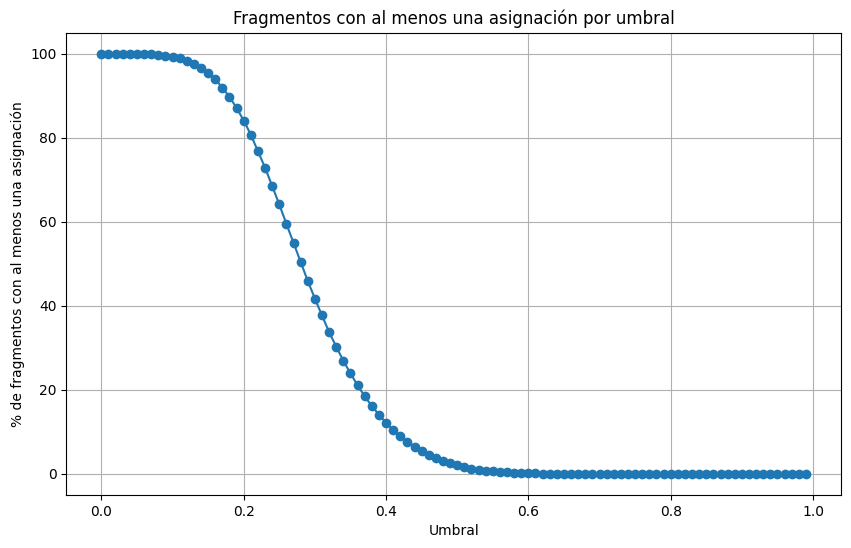

In [16]:
# Graficar chunks con al menos una categoría por umbral
umbrales = np.arange(0, 1, 0.01)
chunks_con_asignacion = []

subcat_cols = resultado.columns[3:20]  # columnas de subcategorías

# Crear DataFrame temporal como float 
sim_temp = resultado[subcat_cols].astype(float)

# Contar chunks con al menos una asignación por umbral
for umbral in umbrales:
    asignados = (sim_temp >= umbral).any(axis=1).sum()  # True si al menos una columna supera el umbral
    chunks_con_asignacion.append(asignados/len(resultado) * 100)  # porcentaje

# Graficar
plt.figure(figsize=(10,6))
plt.plot(umbrales, chunks_con_asignacion, marker='o')
plt.xlabel("Umbral")
plt.ylabel("% de fragmentos con al menos una asignación")
plt.title("Fragmentos con al menos una asignación por umbral")
plt.grid(True)
plt.show()

In [17]:
# Guardar en la carpeta figures
plt.figure(figsize=(10,6))
plt.plot(umbrales, chunks_con_asignacion, marker='o')
plt.xlabel("Umbral")
plt.ylabel("% de fragmentos con al menos una asignación")
plt.title("Distribución fragmentos elegidos por umbral")
plt.tight_layout()
plt.savefig("../reports/ideas PAPERS/figures/dist_umbral.png", dpi=300)
plt.close()

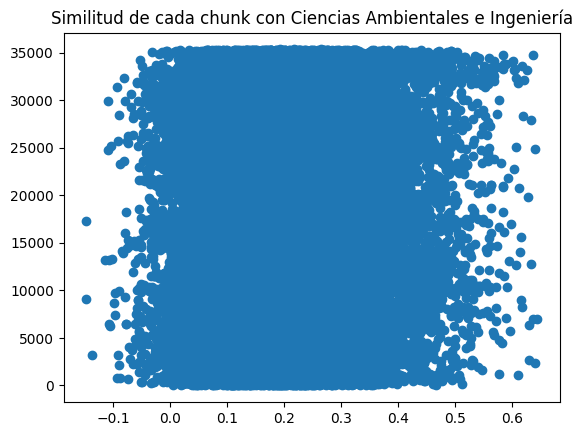

In [18]:
plt.scatter(sim_temp['Ciencias_ambientales_ingenieria'], range(len(sim_temp)))

plt.title('Similitud de cada chunk con Ciencias Ambientales e Ingeniería')
plt.show()

In [19]:
descriptivos = sim_temp.describe()

In [20]:
# Trasponer los descriptivos
descriptivos.T

,count,mean,std,min,25%,50%,75%,max
Ciencias_ambientales_ingenieria,35319.0,0.198638,0.107010,-0.146961,0.122468,0.189745,0.265576,0.643296
Ciencias_espacio,35319.0,0.132466,0.076742,-0.129060,0.080179,0.125368,0.176333,0.560584
Ciencias_fisicas,35319.0,0.094328,0.069323,-0.129393,0.046634,0.088123,0.134822,0.500449
Ciencias_Geografia_oceanografia,35319.0,0.164282,0.085702,-0.133763,0.106531,0.162311,0.218513,0.589887
Ciencias_medicas,35319.0,0.161658,0.075403,-0.100229,0.111164,0.155892,0.203993,0.575557
Ciencias_metereologia,35319.0,0.150030,0.085362,-0.156626,0.093298,0.145275,0.200294,0.606772
Ciencias_naturales,35319.0,0.169840,0.079327,-0.084932,0.115380,0.163044,0.218023,0.552109
Ciencias_polucion_catastrofes_seguridad,35319.0,0.236219,0.097067,-0.092933,0.169488,0.231463,0.298562,0.615902
Ciencias_quimicas,35319.0,0.069489,0.071282,-0.170763,0.020035,0.063881,0.111581,0.475123
Ciencias_tierra,35319.0,0.167307,0.082146,-0.120377,0.111980,0.164218,0.217980,0.588235
